In [1]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from otx.backend.native.models.detection.yolox import YOLOX
from otx.backend.native.models.base import DataInputParams
from otx.data.entity.torch import OTXDataBatch, OTXPredBatch
from otx.data.entity.base import ImageInfo

DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using device: {DEVICE}")

COCO_CLASSES = [
    "person", "bicycle", "car", "motorcycle", "airplane", "bus", "train", "truck",
    "boat", "traffic light", "fire hydrant", "stop sign", "parking meter", "bench",
    "bird", "cat", "dog", "horse", "sheep", "cow", "elephant", "bear", "zebra",
    "giraffe", "backpack", "umbrella", "handbag", "tie", "suitcase", "frisbee",
    "skis", "snowboard", "sports ball", "kite", "baseball bat", "baseball glove",
    "skateboard", "surfboard", "tennis racket", "bottle", "wine glass", "cup",
    "fork", "knife", "spoon", "bowl", "banana", "apple", "sandwich", "orange",
    "broccoli", "carrot", "hot dog", "pizza", "donut", "cake", "chair", "couch",
    "potted plant", "bed", "dining table", "toilet", "tv", "laptop", "mouse",
    "remote", "keyboard", "cell phone", "microwave", "oven", "toaster", "sink",
    "refrigerator", "book", "clock", "vase", "scissors", "teddy bear",
    "hair drier", "toothbrush",
]

/Users/omkar/otx/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/omkar/otx/.venv/lib/python3.12/site-packages/openvino/runtime/__init__.py:10: DeprecationWarning: The `openvino.runtime` module is deprecated and will be removed in the 2026.0 release. Please replace `openvino.runtime` with `openvino`.
  warnings.warn(
/Users/omkar/otx/.venv/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.0.1)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(
Could not find wandb. To use this feature, ensure that you have wandb installed.


Using device: mps


In [2]:
def load_model(model_name="yolox_tiny", device=DEVICE):
    """Load a pretrained YOLOX model ready for inference."""
    model = YOLOX(
        label_info=80,
        data_input_params=DataInputParams(
            input_size=(416, 416),
            mean=(123.675, 116.28, 103.53),
            std=(58.395, 57.12, 57.375),
        ),
        model_name=model_name,
    )
    model.eval()
    model.to(device)
    return model

model = load_model()
print(f"Model: {model.model_name} | Input: {model.data_input_params.input_size} | Classes: {model.num_classes}")

Model: yolox_tiny | Input: (416, 416) | Classes: 80


In [4]:
def get_frame(video_path, frame_idx):
    """Read a single frame (BGR) from a video file."""
    cap = cv2.VideoCapture(str(video_path))
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, frame = cap.read()
    cap.release()
    if not ret:
        raise ValueError(f"Failed to read frame {frame_idx} from {video_path}")
    return frame


def build_otx_batch(frame_bgr, model, device):
    """Preprocess a BGR frame into an OTXDataBatch for model inference."""
    input_size = model.data_input_params.input_size
    mean = model.data_input_params.mean
    std = model.data_input_params.std

    ori_h, ori_w = frame_bgr.shape[:2]
    target_h, target_w = input_size

    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(frame_rgb, (target_w, target_h))
    tensor = torch.from_numpy(resized).permute(2, 0, 1).float()
    tensor = (tensor - torch.tensor(mean).view(3, 1, 1)) / torch.tensor(std).view(3, 1, 1)

    img_info = ImageInfo(
        img_idx=0,
        img_shape=(target_h, target_w),
        ori_shape=(ori_h, ori_w),
        scale_factor=(target_h / ori_h, target_w / ori_w),
    )
    return OTXDataBatch(batch_size=1, images=tensor.unsqueeze(0).to(device), imgs_info=[img_info])


def detect_frame(model, frame_bgr, device, conf_threshold=0.3):
    """Run detection on a single BGR frame.

    Returns: numpy array (N, 6) — [x1, y1, x2, y2, score, class_id]
    """
    batch = build_otx_batch(frame_bgr, model, device)
    with torch.no_grad():
        preds: OTXPredBatch = model.predict_step(batch, batch_idx=0)

    scores = preds.scores[0].cpu().numpy()
    bboxes = preds.bboxes[0].cpu().numpy()
    labels = preds.labels[0].cpu().numpy()

    mask = scores > conf_threshold
    scores, bboxes, labels = scores[mask], bboxes[mask], labels[mask]

    if len(scores) == 0:
        return np.empty((0, 6))
    return np.column_stack([bboxes, scores, labels])


def plot_detections(frame_bgr, detections, class_names=COCO_CLASSES, title="Detections", figsize=(12, 8)):
    """Plot a frame with detection bounding boxes."""
    fig, ax = plt.subplots(1, figsize=figsize)
    ax.imshow(cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB))

    colors = plt.cm.tab20(np.linspace(0, 1, 20))
    for det in detections:
        x1, y1, x2, y2, score, cls_id = det
        cls_id = int(cls_id)
        color = colors[cls_id % 20]
        label = f"{class_names[cls_id]} {score:.2f}"
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                  linewidth=2, edgecolor=color, facecolor="none")
        ax.add_patch(rect)
        ax.text(x1, y1 - 4, label, color="white", fontsize=8,
                bbox=dict(facecolor=color, alpha=0.7, pad=1, edgecolor="none"))

    ax.set_title(title)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

/Users/omkar/otx/.venv/lib/python3.12/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4383.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


4 detections


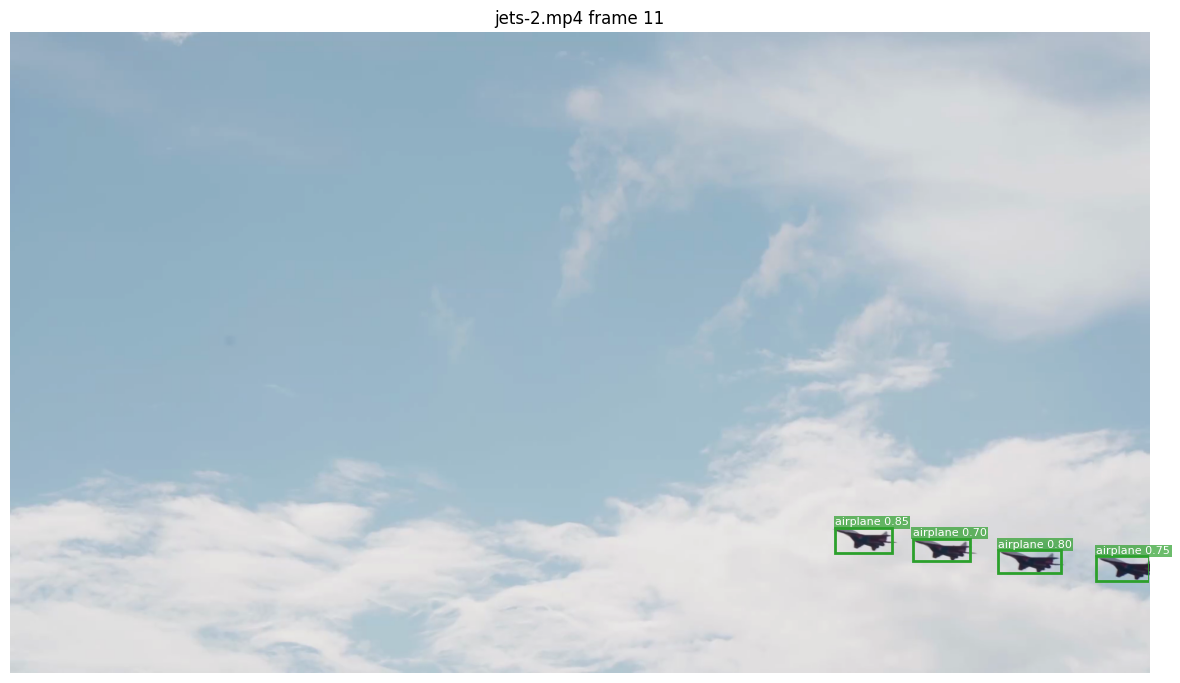

In [5]:
# Test: detect on a single frame and plot
frame = get_frame("videos/original/jets-2.mp4", frame_idx=11)
dets = detect_frame(model, frame, DEVICE, conf_threshold=0.3)
print(f"{len(dets)} detections")
plot_detections(frame, dets, title="jets-2.mp4 frame 11")

10 detections


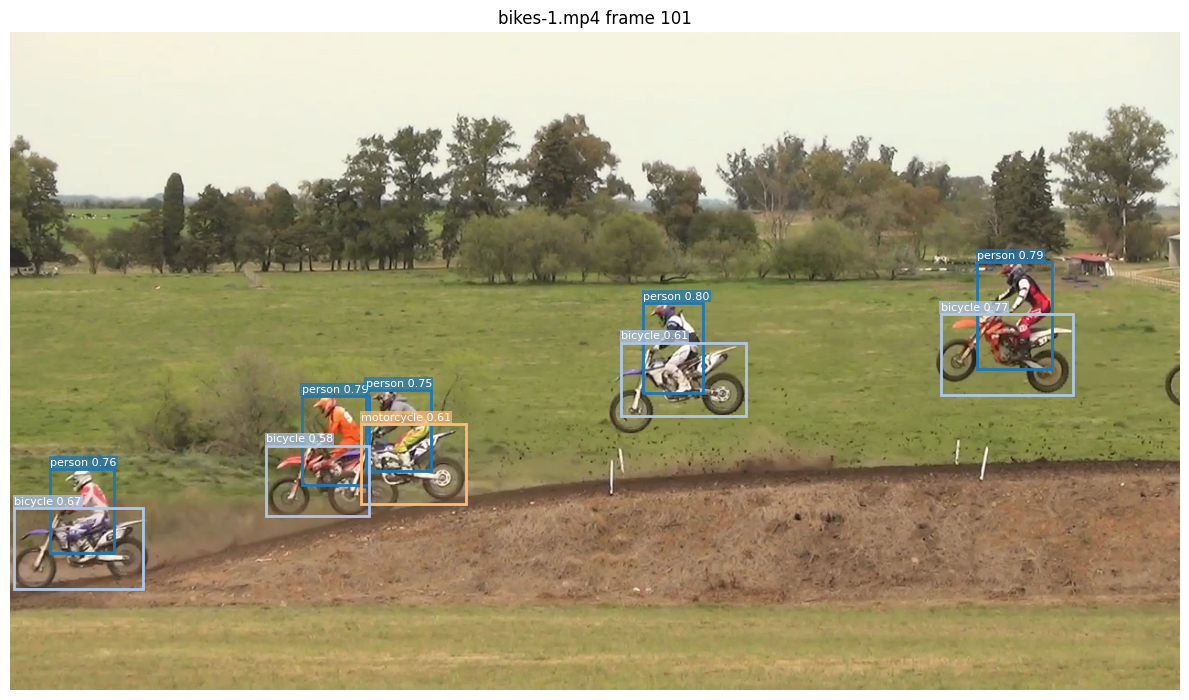

In [6]:
# Test: detect on a single frame and plot
frame = get_frame("videos/original/bikes-1.mp4", frame_idx=101)
dets = detect_frame(model, frame, DEVICE, conf_threshold=0.3)
print(f"{len(dets)} detections")
plot_detections(frame, dets, title="bikes-1.mp4 frame 101")